# Fixed-core weighting assessment against eddy tilt

Compare Gaussian and uniform weighting only within the same `FRAC=1` physical core. The tilt association is an evaluation, not a criterion for changing the boundary.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / "seacofs_tilt_tools.py").exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError("Run inside seacofs_eddy_tilt_analysis or one of its subfolders")
for path in (ANALYSIS_ROOT, HERE):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))
import seacofs_tilt_tools as tilt
import esp_pv_tools as ept
sns.set_theme(style="whitegrid", context="notebook")
palette = {"AE":"#c44e52", "CE":"#4c72b0"}


In [2]:
data=ept.load_cache(); score=ept.eddy_equal_scorecard(data,min_tilt_km=5)

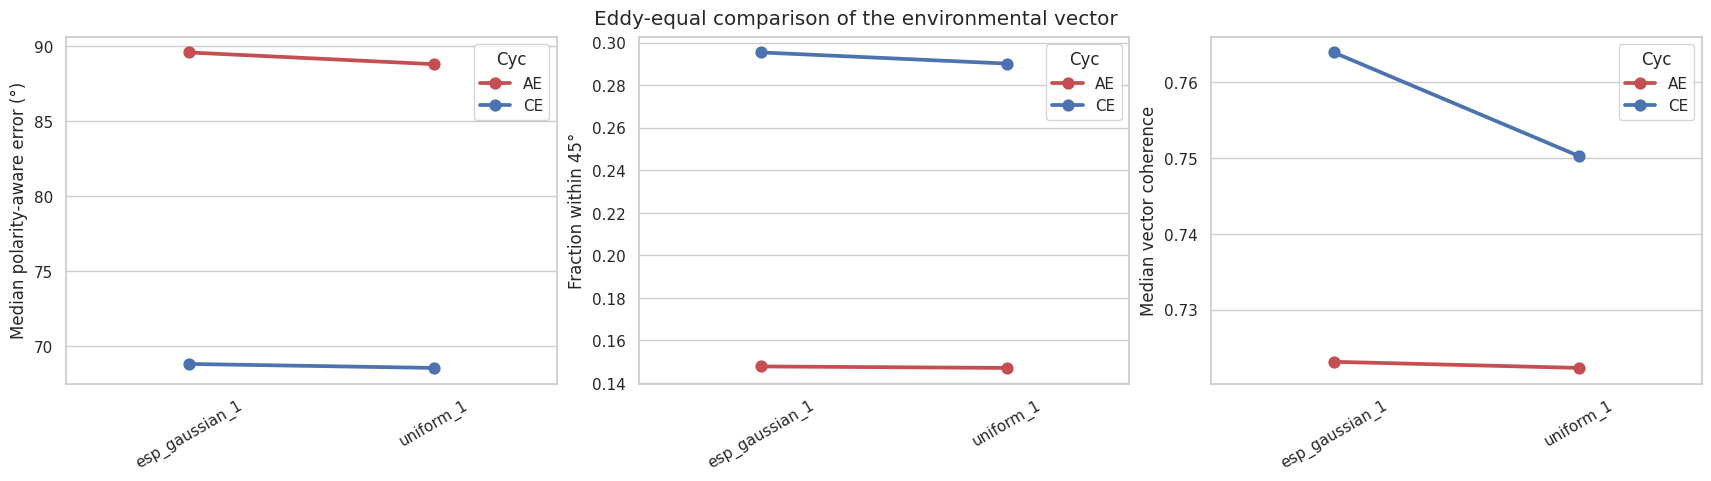

In [3]:
fig,axes=plt.subplots(1,3,figsize=(17,4.7),constrained_layout=True)
metrics=[("environmental_error","Median polarity-aware error (°)"),("environmental_within_45","Fraction within 45°"),("coherence","Median vector coherence")]
for ax,(metric,label) in zip(axes,metrics):
    sns.pointplot(data=score,x="method",y=metric,hue="Cyc",palette=palette,ax=ax)
    ax.set(xlabel="",ylabel=label); ax.tick_params(axis="x",rotation=30)
fig.suptitle("Eddy-equal comparison of the environmental vector"); plt.show()

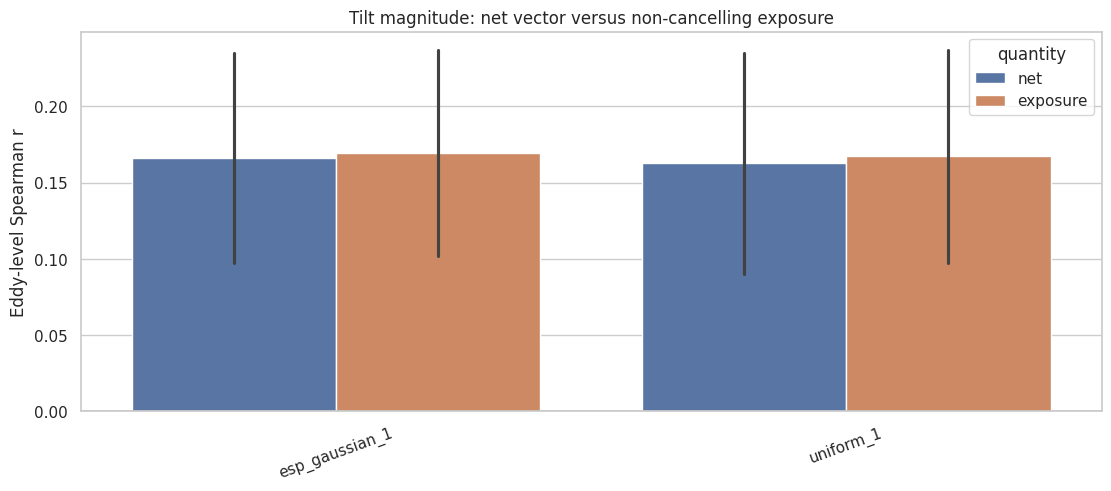

In [4]:
focus=data[data.TiltDis.ge(5)].copy()
eddy=(focus.groupby(["Cyc","method","Eddy"]).agg(
    tilt=("TiltDis","median"),gradient=("PV_grad_mag","median"),
    exposure=("PV_grad_mean_local_mag","median")).reset_index())
records=[]
for (cyc,method), part in eddy.groupby(["Cyc","method"]):
    records.extend([
        {"Cyc":cyc,"method":method,"quantity":"net","spearman_r":part.tilt.corr(part.gradient,method="spearman")},
        {"Cyc":cyc,"method":method,"quantity":"exposure","spearman_r":part.tilt.corr(part.exposure,method="spearman")},
    ])
corr=pd.DataFrame(records)
fig,ax=plt.subplots(figsize=(11,4.8),constrained_layout=True)
sns.barplot(data=corr,x="method",y="spearman_r",hue="quantity",ax=ax)
ax.axhline(0,color="k",lw=1); ax.tick_params(axis="x",rotation=20)
ax.set(xlabel="",ylabel="Eddy-level Spearman r",title="Tilt magnitude: net vector versus non-cancelling exposure")
plt.show()

## Interpretation rule

`esp_gaussian_1` is the primary method because it uses the complete ESP structure while remaining strictly inside the radius-of-maximum-velocity core. Report its environmental `PV_grad_mag` and `PV_grad_theta` as the single forcing estimate. Use local magnitude and coherence to identify strong-but-cancelling bathymetric exposure, and treat the internal/full vectors as secondary physical diagnostics.